#Analisis de Churn - Empresa de Telecomunicaciones

## Objetivo:
Identificar las principales variables de fuga de clientes con el fin de mejorar su estrategia de retencion.


## Resumen ejecutivo: Conclusiones obtenidas y recomendaciones propuestas

**Contexto:** Se analizaron 7043 clientes de una empresa de telecomunicaciones
para identificar qué factores se asocian a la cancelación del servicio.

**Resultados:**
- La tasa general de cancelación es de (__26.5 %__), por encima del benchmark
  de la industria (__15-25%__).
- Los clientes con contrato *Month-to-Month* cancelan (__45 % vs 2.5% y 10.7__) de los contratos de dos años y un año respectivamente. Y quienes cancelan pagan más (73.02 $ vs 59.29 $ al mes).
- Los que cancelan tienen una satisfacción promedio de __1.74 vs 3.79__ de los que se quedan.
- La antigüedad promedio de quienes cancelan es de __17.98 meses vs 37.59__ de quienes permanecen.
- Los clientes con (__Internet Fiber Optic__) tienen la mayor tasa de cancelación (__40.7__%).

**Recomendación:** Investigar los precios de la competencia para el segmento
Month-to-Month y ajustar tarifas donde haga falta. Además, diseñar promociones
que incentiven la migración a contratos de 1 o 2 años, que cancelan mucho menos
(10.7% y 2.55%).

In [ ]:
import pandas as pd


In [ ]:

df = pd.read_csv("telco.csv")
df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [ ]:
df = pd.read_csv("telco.csv")
df.head()


,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [ ]:
df.shape

(7043, 50)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

In [ ]:
df["Churn Label"].value_counts()

,count
Churn Label,
No,5174
Yes,1869


In [ ]:
cantidad_yes = len(df[df["Churn Label"] == "Yes"])
print(cantidad_yes)

1869


In [ ]:
total_clientes = len(df)
print(total_clientes)

7043


## Tasa general de cancelación (Churn Rate)
Antes de investigar las causas, calculamos qué porcentaje de clientes cancelaron el servicio.

In [ ]:
Churn_rate = cantidad_yes / total_clientes
print(Churn_rate)

0.2653698707936959


**Hallazgo:** la tasa de cancelación es de 26.5%, por encima del rango saludable
de la industria (15-25%), lo que indica un problema de retención significativo.

In [ ]:
df.groupby("Churn Label")["Satisfaction Score"].mean()

,Satisfaction Score
Churn Label,
No,3.789911
Yes,1.736223


**Metodología:** se agruparon los clientes según si cancelaron o no,
calculando el promedio de puntaje de satisfacción en cada grupo.

**Hallazgo:** la insatisfacción está fuertemente ligada a la cancelación
del servicio (promedio 1.74/5 en clientes que cancelaron vs 3.79/5 en
los que se quedaron).

In [ ]:
print(df["Satisfaction Score"].min())
print(df["Satisfaction Score"].max())

1
5


In [ ]:
df.groupby("Churn Label")[ "Avg Monthly GB Download"].mean()


,Avg Monthly GB Download
Churn Label,
No,19.915733
Yes,22.175495


**Hallazgo:** los clientes que cancelaron consumen en promedio 22.2 GB mensuales,
levemente más que los 19.9 GB de los que se quedaron. La diferencia es pequeña,
por lo que este dato por sí solo no parece ser un predictor fuerte de churn.
Posible variable de confusión: tipo de contrato o cargos extra por exceso de datos.

In [ ]:
df.groupby("Churn Label")["Tenure in Months"].mean()

,Tenure in Months
Churn Label,
No,37.591225
Yes,17.979133


## Antigüedad del cliente (Tenure) vs Cancelación

**Predicción:** se esperaba que los clientes con menor antigüedad tuvieran mayor
probabilidad de cancelar, ya que al no tener una relación consolidada con la
empresa ni sentido de fidelidad, se encuentran en una especie de "período de
prueba" evaluando otras opciones del mercado.

**Metodología:** se agruparon los clientes según si cancelaron o no, calculando
el promedio de antigüedad (en meses) para cada grupo.

**Hallazgo:** la predicción se confirmó con fuerza. Los clientes que cancelaron
tienen en promedio 17.98 meses de antigüedad, frente a 37.59 meses de los
clientes que permanecen — más del doble. Esto sugiere que la antigüedad es
un fuerte predictor de churn, especialmente relevante para diseñar estrategias
de retención enfocadas en los primeros 1-2 años del cliente.

In [ ]:
pd.crosstab(df["Contract"], df["Churn Label"])

Churn Label,No,Yes
Contract,,
Month-to-Month,1955,1655
One Year,1384,166
Two Year,1835,48


In [ ]:
df_mensual = df[df["Contract"] == "Month-to-Month"]
df_mensual.shape


(3610, 50)

In [ ]:

df_mensual.groupby("Churn Label")["Monthly Charge"].mean()

,Monthly Charge
Churn Label,
No,59.293632
Yes,73.019396


## Precio mensual dentro de clientes Month-to-Month

**Contexto:** dado que Month-to-Month es el segmento con mayor cancelación (45%),
se investigó si el precio mensual influye en la decisión de cancelar dentro de
este grupo específico.

**Metodología:** se filtró el dataset para incluir solo clientes con contrato
Month-to-Month, y se calculó el precio mensual promedio comparando quienes
cancelaron vs quienes no.

**Hallazgo:** los clientes que cancelaron pagaban en promedio $73.02/mes, un
23% más caro que los $59.29/mes de quienes permanecen. Esto sugiere que, dentro
del segmento de mayor riesgo, el precio es un factor relevante en la decisión
de cancelación — posiblemente por percepción de mejor relación costo-beneficio
en ofertas de la competencia.

**Recomendación:** (1) realizar un análisis comparativo de precios frente a la
competencia para el segmento Month-to-Month, y (2) diseñar promociones que
incentiven la migración hacia contratos de 1 o 2 años, dado que estos muestran
tasas de cancelación significativamente menores (10.7% y 2.55% respectivamente).

In [ ]:
df["Internet Type"].value_counts(dropna=False)

,count
Internet Type,
Fiber Optic,3035
DSL,1652
NaN,1526
Cable,830


In [ ]:
pd.crosstab(df["Internet Type"],df["Churn Label"])

Churn Label,No,Yes
Internet Type,,
Cable,617,213
DSL,1345,307
Fiber Optic,1799,1236


In [ ]:
import matplotlib.pyplot as plt


In [ ]:
contratos = ["Month-to-Month", "One Year", "Two Year"]
porcentajes = [45, 10.7, 2.55]

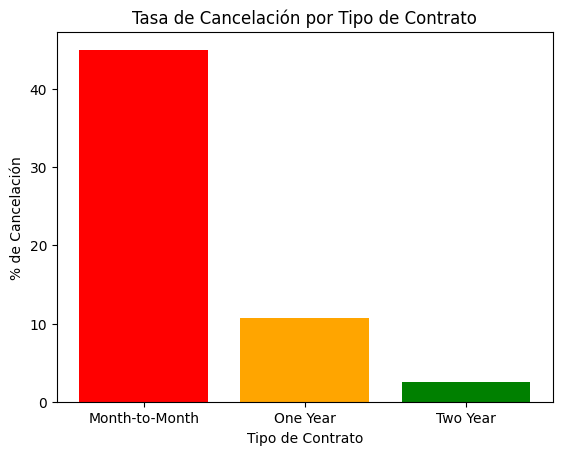

In [ ]:
colores = ["red", "orange", "green"]
plt.bar(contratos, porcentajes, color=colores)
plt.title("Tasa de Cancelación por Tipo de Contrato")
plt.xlabel("Tipo de Contrato")
plt.ylabel("% de Cancelación")
plt.show()

### Visualizacion:Cancelacion por tipo de contrato
El gráfico confirma que los contratos Month-to-Month concentran la mayor
tasa de cancelación (45%), muy por encima de contratos anuales o bianuales.

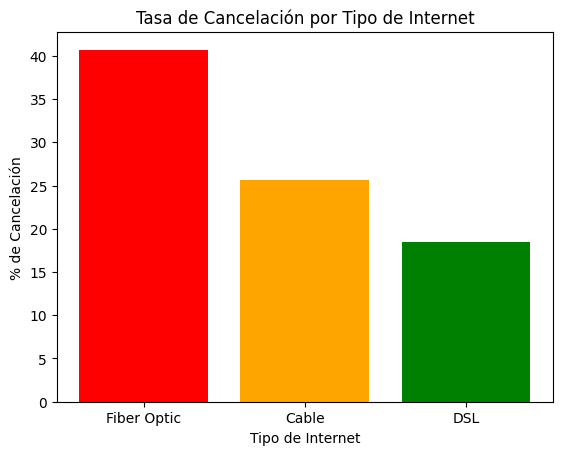

In [ ]:
tipos_internet = ["Fiber Optic", "Cable", "DSL"]
porcentajes_internet = [40.7, 25.6, 18.5]
colores_internet = ["red", "orange", "green"]

plt.bar(tipos_internet, porcentajes_internet, color=colores_internet)
plt.title("Tasa de Cancelación por Tipo de Internet")
plt.xlabel("Tipo de Internet")
plt.ylabel("% de Cancelación")
plt.show()

### Visualizacion de tasa de cancelacion por tipo de internet
Este grafico confirma que el porcentaje de mayor cancelacion esta en el de fibra optica con 40.7 % de clientes que cancelaron el servicio.

In [ ]:
indice_de_satisfaccion = ["NO cancelaron", "SI cancelaron"]
promedio_de_satisfaccion = [3.79, 1.74]
colores = ["blue", "red"]



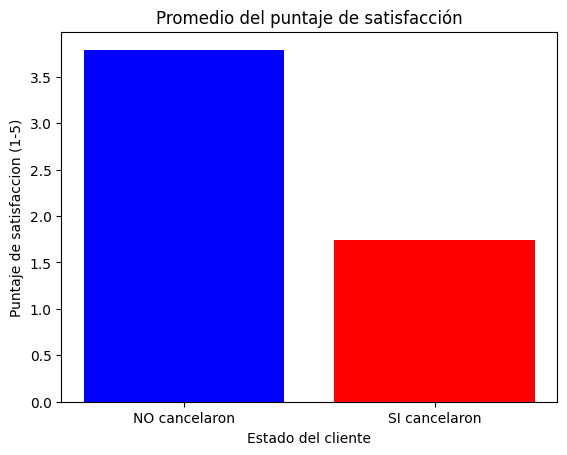

In [ ]:
plt.bar(indice_de_satisfaccion, promedio_de_satisfaccion, color=colores)
plt.title("Promedio del puntaje de satisfacción")
plt.xlabel("Estado del cliente")
plt.ylabel("Puntaje de satisfaccion (1-5)")
plt.show()

###Visualizacion del promedio del puntaje de satisfaccion
En este grafico se visualiza la comparativa de satisfaccion entre clientes que NO cancelaron y aquellos que SI, tomadno en cuenta una escala de puntaje de 1 a 5, siendo 1 baja satisfaccion y 5 un alto contentamiento.

**Hallazgo**:
los clientes que cancelaron tienen una satisfacción promedio de
1.74, frente a 3.79 de los que se quedaron: una brecha de más de 2 puntos.
Esto indica que un puntaje bajo de satisfacción es una señal de alerta temprana
de cancelación
